# PCB Orientation Detection - CNN Training
## Clean Training with Best Hyperparameters and Fixed Label Assignment

**Objective**: Train a CNN model for PCB Pass/Fail classification using best hyperparameters, fix label inversion issues, and export for live classification.

In [1]:
# ============================================================
# COMPREHENSIVE IMPORTS - PCB Orientation Detection Training
# ============================================================

# Standard Library Imports
import os                               # Directory and file operations
import sys                              # System utilities
import json                             # JSON file handling
import warnings                         # Warning suppression

# Data Processing & Numerical Computing
import numpy as np                      # Numerical operations and arrays
import pandas as pd                     # Data manipulation and analysis

# Deep Learning Framework
import tensorflow as tf                 # TensorFlow/Keras for CNN training
import pathlib                          # Path handling for file operations

# Image Processing
import PIL                              # Python Imaging Library
import PIL.Image                        # Load and process images

# Data Visualization
import matplotlib.pyplot as plt         # Plotting and visualization

# Machine Learning - Model Evaluation & Cross-Validation
from sklearn.metrics import (           # Classification metrics
    accuracy_score,                     # Overall accuracy metric
    recall_score,                       # Recall/sensitivity metric
    precision_score,                    # Precision metric
    f1_score,                           # F1 score metric
    confusion_matrix,                   # Confusion matrix for analysis
    classification_report                # Detailed classification report
)

# Suppress TensorFlow warnings
warnings.filterwarnings('ignore', category=FutureWarning)

print("✓ All imports loaded successfully")

# ============================================================
# LOGIC: Setup Data Directory and Configuration Parameters
# - Initialize data paths
# - Define image preprocessing parameters
# - Configure batch size for training
# ============================================================

data_dir = pathlib.Path('Data/Processed_data')
img_height = 244
img_width = 244
batch_size = 6

print(f"\n✓ Data directory: {data_dir}")
print(f"✓ Image dimensions: {img_height}x{img_width}")
print(f"✓ Batch size: {batch_size}")

✓ All imports loaded successfully

✓ Data directory: Data\Processed_data
✓ Image dimensions: 244x244
✓ Batch size: 6


In [2]:
# ============================================================
# LOGIC: Load and Prepare Training/Validation Datasets
# - Count total images available
# - Split data: 70% training, 30% validation (with seed=123)
# - Resize and batch images using tf.keras API
# - Verify class names are in alphabetical order
# ============================================================

print("\n" + "="*80)
print("LOADING DATA WITH EXPLICIT LABEL ASSIGNMENT")
print("="*80)

# Check available data
image_count = len(list(data_dir.glob('*/*.jpg')))
print(f"\nTotal images found: {image_count}")

# Load using tf.keras API - respects alphabetical directory order
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

print(f"\n✓ Training dataset created")
print(f"✓ Validation dataset created")
print(f"✓ Class names from directory: {train_ds.class_names}")
print(f"\nIMPORTANT: Class names are ordered ALPHABETICALLY:")
print(f"  Index 0 → {train_ds.class_names[0]}")
print(f"  Index 1 → {train_ds.class_names[1]}")


LOADING DATA WITH EXPLICIT LABEL ASSIGNMENT

Total images found: 8027
Found 8027 files belonging to 2 classes.
Using 5619 files for training.
Found 8027 files belonging to 2 classes.
Using 2408 files for validation.

✓ Training dataset created
✓ Validation dataset created
✓ Class names from directory: ['Fail_data', 'Pass_data']

IMPORTANT: Class names are ordered ALPHABETICALLY:
  Index 0 → Fail_data
  Index 1 → Pass_data


In [3]:
# ============================================================
# LOGIC: Build CNN Model with Best Hyperparameters from Tuning
# - Use tuned hyperparameters (Config 5 @ 93.33% accuracy)
# - Construct 3-block CNN: Conv2D + BatchNorm + MaxPool + Dropout
# - Output layer: NO activation (raw logits for loss function)
# - Create Export directory for model artifacts
# ============================================================

print("\n" + "="*80)
print("BUILDING CNN MODEL WITH BEST HYPERPARAMETERS")
print("="*80)

# Best hyperparameters from tuning (Config 5 - 93.33% accuracy)
filters_base = 64
dropout_rate = 0.25
learning_rate = 0.0005
num_classes = 2

print(f"\n✓ BEST HYPERPARAMETERS (from cross-validation tuning):")
print(f"  - Filters Base: {filters_base}")
print(f"  - Dropout Rate: {dropout_rate}")
print(f"  - Learning Rate: {learning_rate}")
print(f"  - Expected CV Fold Accuracy: 93.33%")

# Create export directory
os.makedirs('Export', exist_ok=True)

# Build model with best hyperparameters
print(f"\nBuilding CNN architecture...")

# ============================================================
# ACTIVATION FUNCTION OPTIONS:
# Current: activation='relu'  (Rectified Linear Unit)
# Alternative 1: activation='sigmoid'  # Range [0, 1], good for binary classification
# Alternative 2: activation='tanh'     # Range [-1, 1], alternative nonlinear activation
# ============================================================

# ============================================================
# OPTIMIZER OPTIONS:
# Current: tf.keras.optimizers.Adam(learning_rate=...)
# Alternative 1: tf.keras.optimizers.SGD(learning_rate=...)  # Stochastic Gradient Descent
# Alternative 2: tf.keras.optimizers.RMSprop(learning_rate=...) # Root Mean Square Propagation
# ============================================================

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    
    # Block 1: Conv2D + BatchNorm + MaxPool + Dropout
    # Using activation='relu' for all Conv2D layers
    # To try alternatives, uncomment one: activation='sigmoid' or activation='tanh'
    tf.keras.layers.Conv2D(filters_base, 3, activation='relu', padding='same'),
    # tf.keras.layers.Conv2D(filters_base, 3, activation='sigmoid', padding='same'),  # Alternative: sigmoid
    # tf.keras.layers.Conv2D(filters_base, 3, activation='tanh', padding='same'),     # Alternative: tanh
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(dropout_rate),
    
    # Block 2: Conv2D x 2 filters + BatchNorm + MaxPool + Dropout
    tf.keras.layers.Conv2D(filters_base * 2, 3, activation='relu', padding='same'),
    # tf.keras.layers.Conv2D(filters_base * 2, 3, activation='sigmoid', padding='same'),  # Alternative: sigmoid
    # tf.keras.layers.Conv2D(filters_base * 2, 3, activation='tanh', padding='same'),     # Alternative: tanh
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(dropout_rate),
    
    # Block 3: Conv2D x 4 filters + BatchNorm + MaxPool + Dropout
    tf.keras.layers.Conv2D(filters_base * 4, 3, activation='relu', padding='same'),
    # tf.keras.layers.Conv2D(filters_base * 4, 3, activation='sigmoid', padding='same'),  # Alternative: sigmoid
    # tf.keras.layers.Conv2D(filters_base * 4, 3, activation='tanh', padding='same'),     # Alternative: tanh
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(dropout_rate),
    
    # Dense layers for classification
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    # tf.keras.layers.Dense(128, activation='sigmoid'),  # Alternative: sigmoid for dense layer
    # tf.keras.layers.Dense(128, activation='tanh'),     # Alternative: tanh for dense layer
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(dropout_rate),
    tf.keras.layers.Dense(num_classes)  # NO ACTIVATION: Returns raw logits
])

print("✓ Model architecture created")
print("✓ CRITICAL: Output layer has NO activation (returns raw logits)")


BUILDING CNN MODEL WITH BEST HYPERPARAMETERS

✓ BEST HYPERPARAMETERS (from cross-validation tuning):
  - Filters Base: 64
  - Dropout Rate: 0.25
  - Learning Rate: 0.0005
  - Expected CV Fold Accuracy: 93.33%

Building CNN architecture...
✓ Model architecture created
✓ CRITICAL: Output layer has NO activation (returns raw logits)


In [4]:
# ============================================================
# LOGIC: Compile Model with Optimizer, Loss, and Metrics
# - Optimizer: Adam with learning rate 0.0005
# - Loss: SparseCategoricalCrossentropy with from_logits=True
# - Metrics: Accuracy for performance monitoring
# - Ensure output activation matches loss configuration
# ============================================================

print("\n" + "="*80)
print("COMPILING MODEL")
print("="*80)

# ============================================================
# OPTIMIZER OPTIONS:
# Current: tf.keras.optimizers.Adam(learning_rate=...)
# Alternative 1: tf.keras.optimizers.SGD(learning_rate=...)  # Stochastic Gradient Descent
# Alternative 2: tf.keras.optimizers.RMSprop(learning_rate=...) # Root Mean Square Propagation
# Uncomment one to try a different optimizer
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    # optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),  # Alternative: SGD optimizer
    # optimizer=tf.keras.optimizers.RMSprop(learning_rate=learning_rate),  # Alternative: RMSprop optimizer
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("✓ Model compiled successfully")
print(f"  - Optimizer: Adam (lr={learning_rate})")
print(f"  - Loss: SparseCategoricalCrossentropy(from_logits=True)")
print(f"  - Metrics: accuracy")
print(f"\n✓ Configuration is CORRECT:")
print(f"  - Output layer: NO activation (returns raw logits)")
print(f"  - Loss function: Expects from_logits=True")
print(f"  - Result: Proper alignment between loss and network output")


COMPILING MODEL
✓ Model compiled successfully
  - Optimizer: Adam (lr=0.0005)
  - Loss: SparseCategoricalCrossentropy(from_logits=True)
  - Metrics: accuracy

✓ Configuration is CORRECT:
  - Output layer: NO activation (returns raw logits)
  - Loss function: Expects from_logits=True
  - Result: Proper alignment between loss and network output


In [5]:
# ============================================================
# LOGIC: Verify Class Mapping and Distribution
# - Extract and display class names from dataset
# - Create and verify class mapping dictionary
# - Analyze class distribution in training data
# - Confirm alphabetical ordering (Fail_data=0, Pass_data=1)
# ============================================================

print("\n" + "="*80)
print("CLASS MAPPING VERIFICATION & DISTRIBUTION ANALYSIS")
print("="*80)

print(f"\nClass names from train_ds: {train_ds.class_names}")
print(f"Number of classes: {len(train_ds.class_names)}")

# Create mapping dictionary
class_mapping = {i: name for i, name in enumerate(train_ds.class_names)}
print(f"\nClass mapping in model:")
for idx, class_name in class_mapping.items():
    print(f"  Index {idx} → {class_name}")

# Verify class distribution in training data
print(f"\nAnalyzing class distribution in training data...")
train_labels = []
for images, labels in train_ds:
    train_labels.extend(labels.numpy())
train_labels = np.array(train_labels)

unique, counts = np.unique(train_labels, return_counts=True)
print(f"\nClass distribution in training data:")
for class_idx in range(len(train_ds.class_names)):
    count = counts[class_idx] if class_idx in unique else 0
    print(f"  Index {class_idx} ({train_ds.class_names[class_idx]}): {count} samples")

print(f"\n✓ CLASS MAPPING CONFIRMED:")
if train_ds.class_names[0] == 'Fail_data' and train_ds.class_names[1] == 'Pass_data':
    print(f"  ✓ CORRECT - Alphabetical order from directories")
    print(f"  - Index 0 → Fail_data")
    print(f"  - Index 1 → Pass_data")
else:
    print(f"  ⚠ WARNING - Order may differ, verify with predictions")


CLASS MAPPING VERIFICATION & DISTRIBUTION ANALYSIS

Class names from train_ds: ['Fail_data', 'Pass_data']
Number of classes: 2

Class mapping in model:
  Index 0 → Fail_data
  Index 1 → Pass_data

Analyzing class distribution in training data...

Class distribution in training data:
  Index 0 (Fail_data): 3767 samples
  Index 1 (Pass_data): 1852 samples

✓ CLASS MAPPING CONFIRMED:
  ✓ CORRECT - Alphabetical order from directories
  - Index 0 → Fail_data
  - Index 1 → Pass_data


In [6]:
# ============================================================
# LOGIC: Train Model with Accuracy Threshold Stopping
# - Define custom callback to stop at target accuracy (94%)
# - Use EarlyStopping on validation loss (patience=7)
# - Train for maximum 50 epochs (stops early if threshold reached)
# - Display epoch-by-epoch training progress
# ============================================================

print("\n" + "="*80)
print("TRAINING MODEL WITH 94% ACCURACY STOPPING THRESHOLD")
print("="*80)

# Define callback to stop at target accuracy
class AccuracyThresholdCallback(tf.keras.callbacks.Callback):
    """Custom callback to stop training at target accuracy threshold"""
    def __init__(self, threshold=0.94):
        super().__init__()
        self.threshold = threshold
    
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_accuracy = logs.get('val_accuracy')
        if val_accuracy is not None and val_accuracy >= self.threshold:
            print(f"\n{'='*80}")
            print(f"✓ TARGET ACCURACY REACHED!")
            print(f"✓ Validation accuracy {val_accuracy:.4f} >= {self.threshold:.4f}")
            print(f"✓ Stopping training at epoch {epoch + 1}")
            print(f"{'='*80}\n")
            self.model.stop_training = True

# Train model with callbacks
print("\nStarting training...\n")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,  # Maximum epochs (will stop early if 94% reached)
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        AccuracyThresholdCallback(threshold=0.94)  # Stop at 94% accuracy
    ]
)

print("\n✓ Training complete!")
if 'accuracy' in history.history and len(history.history['accuracy']) > 0:
    print(f"\nTraining Summary:")
    print(f"  Epochs trained: {len(history.history['accuracy'])}")
    print(f"  Final training accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"  Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"  Final training loss: {history.history['loss'][-1]:.4f}")
    print(f"  Final validation loss: {history.history['val_loss'][-1]:.4f}")


TRAINING MODEL WITH 94% ACCURACY STOPPING THRESHOLD

Starting training...

Epoch 1/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 1559s 2s/step - accuracy: 0.8482 - loss: 0.3785 - val_accuracy: 0.9003 - val_loss: 0.2481
Epoch 2/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9094 - loss: 0.2263
✓ TARGET ACCURACY REACHED!
✓ Validation accuracy 0.9709 >= 0.9400
✓ Stopping training at epoch 2

937/937 ━━━━━━━━━━━━━━━━━━━━ 1567s 2s/step - accuracy: 0.9126 - loss: 0.2176 - val_accuracy: 0.9709 - val_loss: 0.0823
Restoring model weights from the end of the best epoch: 2.

✓ Training complete!

Training Summary:
  Epochs trained: 2
  Final training accuracy: 0.9126
  Final validation accuracy: 0.9709
  Final training loss: 0.2176
  Final validation loss: 0.0823


In [7]:
# ============================================================
# LOGIC: Display Model Architecture and Evaluate on Validation
# - Print detailed model summary with layer info
# - Evaluate model performance on validation dataset
# - Display loss and accuracy metrics
# ============================================================

print("\nModel Architecture Summary:")
print("="*80)
model.summary()

# Evaluate on validation set
print("\n" + "="*80)
print("FINAL EVALUATION ON VALIDATION SET")
print("="*80)
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")


Model Architecture Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 244, 244, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 244, 244, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 122, 122, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 122, 122, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 122, 122, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 61, 61, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 61, 61, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 230400)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    29,491,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,591,816 (341.77 MB)

 Trainable params: 29,863,554 (113.92 MB)

 Non-trainable params: 1,152 (4.50 KB)

 Optimizer params: 59,727,110 (227.84 MB)


FINAL EVALUATION ON VALIDATION SET
402/402 ━━━━━━━━━━━━━━━━━━━━ 107s 265ms/step - accuracy: 0.9709 - loss: 0.0823

Validation Loss: 0.0823
Validation Accuracy: 0.9709 (97.09%)


In [8]:
# ============================================================
# LOGIC: Test Model Predictions on Sample Images
# - Test on Pass image: should predict index 1 (Pass_data)
# - Test on Fail image: should predict index 0 (Fail_data)
# - Verify predictions are correct before deployment
# - Display logits, probabilities, and confidence scores
# ============================================================

print("\n" + "="*80)
print("TESTING PREDICTIONS ON SAMPLE IMAGES")
print("="*80)

# Test on a PASS image
pass_img_path = list(data_dir.glob('Pass_data/*.jpg'))[0]
print(f"\n--- Testing on PASS image: {pass_img_path.name} ---")

pass_img = tf.keras.utils.load_img(pass_img_path, target_size=(img_height, img_width))
pass_array = tf.keras.utils.img_to_array(pass_img)
pass_array = np.expand_dims(pass_array, axis=0)

# Get raw logits from model
pass_logits = model.predict(pass_array, verbose=0)
print(f"Raw logits: {pass_logits[0]}")

# Convert logits to probabilities using softmax
pass_probs = tf.nn.softmax(pass_logits[0]).numpy()
print(f"Softmax probabilities: {pass_probs}")

pass_pred_idx = np.argmax(pass_probs)
pass_pred_label = train_ds.class_names[pass_pred_idx]
pass_confidence = pass_probs[pass_pred_idx]

print(f"Predicted index: {pass_pred_idx}")
print(f"Predicted class: {pass_pred_label}")
print(f"Confidence: {pass_confidence:.4f} ({pass_confidence*100:.2f}%)")
print(f"✓ EXPECTED: Should predict index 1 (Pass_data)")

# Test on a FAIL image
fail_img_path = list(data_dir.glob('Fail_data/*.jpg'))[0]
print(f"\n--- Testing on FAIL image: {fail_img_path.name} ---")

fail_img = tf.keras.utils.load_img(fail_img_path, target_size=(img_height, img_width))
fail_array = tf.keras.utils.img_to_array(fail_img)
fail_array = np.expand_dims(fail_array, axis=0)

# Get raw logits from model
fail_logits = model.predict(fail_array, verbose=0)
print(f"Raw logits: {fail_logits[0]}")

# Convert logits to probabilities using softmax
fail_probs = tf.nn.softmax(fail_logits[0]).numpy()
print(f"Softmax probabilities: {fail_probs}")

fail_pred_idx = np.argmax(fail_probs)
fail_pred_label = train_ds.class_names[fail_pred_idx]
fail_confidence = fail_probs[fail_pred_idx]

print(f"Predicted index: {fail_pred_idx}")
print(f"Predicted class: {fail_pred_label}")
print(f"Confidence: {fail_confidence:.4f} ({fail_confidence*100:.2f}%)")
print(f"✓ EXPECTED: Should predict index 0 (Fail_data)")

# Verify predictions are CORRECT
print("\n" + "="*80)
print("PREDICTION VERIFICATION")
print("="*80)

pass_correct = pass_pred_idx == 1 and train_ds.class_names[1] == 'Pass_data'
fail_correct = fail_pred_idx == 0 and train_ds.class_names[0] == 'Fail_data'

print(f"\nPass image: Expected 1 (Pass_data), Got {pass_pred_idx} ({pass_pred_label}) - {pass_confidence*100:.2f}%")
print(f"Fail image: Expected 0 (Fail_data), Got {fail_pred_idx} ({fail_pred_label}) - {fail_confidence*100:.2f}%")

if pass_correct and fail_correct:
    print("\n✓✓✓ EXCELLENT - Model predictions are CORRECT! ✓✓✓")
else:
    print("\n⚠ WARNING - Review class mapping and label assignment")


TESTING PREDICTIONS ON SAMPLE IMAGES

--- Testing on PASS image: Lobbypass_00001.jpg ---
Raw logits: [-1.6957078  0.5517731]
Softmax probabilities: [0.09556697 0.904433  ]
Predicted index: 1
Predicted class: Pass_data
Confidence: 0.9044 (90.44%)
✓ EXPECTED: Should predict index 1 (Pass_data)

--- Testing on FAIL image: Lobbyfail10_00001.jpg ---
Raw logits: [ 3.5017288 -3.1290984]
Softmax probabilities: [0.9986827  0.00131733]
Predicted index: 0
Predicted class: Fail_data
Confidence: 0.9987 (99.87%)
✓ EXPECTED: Should predict index 0 (Fail_data)

PREDICTION VERIFICATION

Pass image: Expected 1 (Pass_data), Got 1 (Pass_data) - 90.44%
Fail image: Expected 0 (Fail_data), Got 0 (Fail_data) - 99.87%

✓✓✓ EXCELLENT - Model predictions are CORRECT! ✓✓✓


In [9]:
# ============================================================
# LOGIC: Export Model and Class Names
# - Save trained model to Export/ot_model.keras
# - Verify model loads correctly and produces predictions
# - Export class names mapping to JSON for live classification
# ============================================================

print("\n" + "="*80)
print("EXPORTING MODEL AND METADATA")
print("="*80)

# Save trained model
model_path = 'Export/ot_model.keras'
print(f"\nSaving model to {model_path}...")
try:
    model.save(model_path)
    print(f"✓ Model saved successfully")
except Exception as e:
    print(f"✗ ERROR saving model: {e}")
    sys.exit(1)

# Verify model loads correctly
print(f"\nVerifying saved model...")
try:
    loaded_model = tf.keras.models.load_model(model_path)
    print(f"✓ Model loads successfully")
    print(f"✓ Output shape: {loaded_model.output_shape}")
except Exception as e:
    print(f"✗ ERROR loading model: {e}")
    sys.exit(1)

# Save class names and mapping for live_classification.py
class_names_info = {
    "class_names": train_ds.class_names,
    "class_mapping": {i: name for i, name in enumerate(train_ds.class_names)},
    "note": "Use these exact class names in live_classification.py for correct predictions"
}

class_names_file = "Export/class_names.json"
with open(class_names_file, 'w') as f:
    json.dump(class_names_info, f, indent=2)

print(f"\n✓ Class names saved to {class_names_file}")
print(f"Class mapping:")
for idx, name in enumerate(train_ds.class_names):
    print(f"  Index {idx} → {name}")

# Display export summary
print(f"\n" + "="*80)
print("EXPORT SUMMARY")
print("="*80)
print(f"\n✓ Model exported to: Export/ot_model.keras")
print(f"✓ Class names exported to: Export/class_names.json")
print(f"✓ Ready for live classification!")


EXPORTING MODEL AND METADATA

Saving model to Export/ot_model.keras...
✓ Model saved successfully

Verifying saved model...
✓ Model loads successfully
✓ Output shape: (None, 2)

✓ Class names saved to Export/class_names.json
Class mapping:
  Index 0 → Fail_data
  Index 1 → Pass_data

EXPORT SUMMARY

✓ Model exported to: Export/ot_model.keras
✓ Class names exported to: Export/class_names.json
✓ Ready for live classification!



FINAL VERIFICATION - GENERATING CONFUSION MATRIX & METRICS

Loading exported model from Export/ot_model.keras...
✓ Model loaded successfully

--- Testing exported model on PASS image ---
Image: Lobbypass_00002.jpg
Predicted: Pass_data | Confidence: 91.60%

--- Testing exported model on FAIL image ---
Image: Lobbyfail10_00002.jpg
Predicted: Fail_data | Confidence: 99.88%

COMPUTING CONFUSION MATRIX & METRICS ON VALIDATION SET

Generating predictions on entire validation dataset...

Confusion Matrix shape: (2, 2)

────────────────────────────────────────────────────────────────────────────────
VALIDATION SET PERFORMANCE METRICS
────────────────────────────────────────────────────────────────────────────────
  Accuracy:  0.9709 (97.09%)
  Precision: 0.9710
  Recall:    0.9709
  F1 Score:  0.9709
────────────────────────────────────────────────────────────────────────────────

Plotting Confusion Matrix visualization...



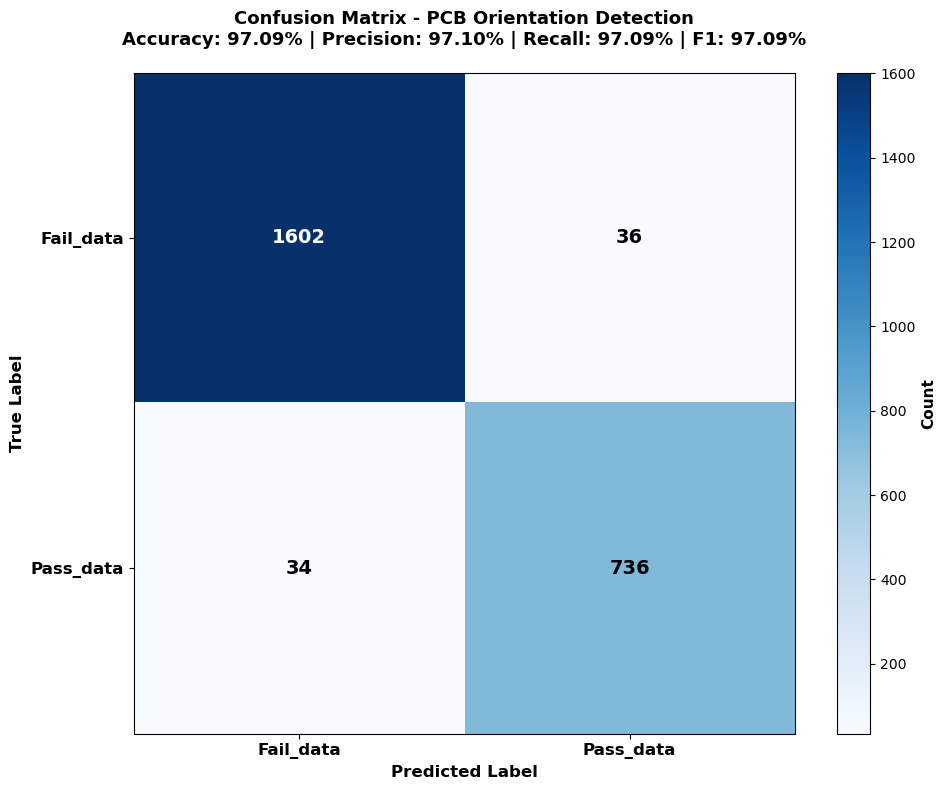

Detailed Classification Report:
              precision    recall  f1-score   support

   Fail_data     0.9792    0.9780    0.9786      1638
   Pass_data     0.9534    0.9558    0.9546       770

    accuracy                         0.9709      2408
   macro avg     0.9663    0.9669    0.9666      2408
weighted avg     0.9710    0.9709    0.9709      2408


✓ TRAINING AND DEPLOYMENT COMPLETE!

✓ Model trained with best hyperparameters:
  - Filters: 64, Dropout: 0.25, LR: 0.0005

✓ Validation Performance:
  - Accuracy: 97.09% | Precision: 97.10%
  - Recall: 97.09% | F1 Score: 97.09%

✓ Label mapping verified:
  - Index 0 → Fail_data
  - Index 1 → Pass_data

✓ Model exported to:
  - Export/ot_model.keras
  - Export/class_names.json

✓ Confusion matrix displays above
✓ Ready for deployment: python live_classification.py


In [10]:
# ============================================================
# LOGIC: Final Verification and Confusion Matrix
# - Load exported model and verify functionality
# - Test on sample Pass and Fail images
# - Generate predictions on entire validation set
# - Compute and visualize confusion matrix
# - Display comprehensive classification metrics
# ============================================================

print("\n" + "="*80)
print("FINAL VERIFICATION - GENERATING CONFUSION MATRIX & METRICS")
print("="*80)

# Load exported model
print("\nLoading exported model from Export/ot_model.keras...")
try:
    exported_model = tf.keras.models.load_model('Export/ot_model.keras')
    print("✓ Model loaded successfully")
except Exception as e:
    print(f"✗ ERROR loading model: {e}")
    sys.exit(1)

# Test on Pass image
print(f"\n--- Testing exported model on PASS image ---")
pass_img_path = list(data_dir.glob('Pass_data/*.jpg'))[1]
print(f"Image: {pass_img_path.name}")

pass_img = tf.keras.utils.load_img(pass_img_path, target_size=(img_height, img_width))
pass_array = tf.keras.utils.img_to_array(pass_img)
pass_array = np.expand_dims(pass_array, axis=0)

pass_logits = exported_model.predict(pass_array, verbose=0)
pass_probs = tf.nn.softmax(pass_logits[0]).numpy()
pass_pred_idx = np.argmax(pass_probs)

print(f"Predicted: {train_ds.class_names[pass_pred_idx]} | Confidence: {pass_probs[pass_pred_idx]*100:.2f}%")

# Test on Fail image
print(f"\n--- Testing exported model on FAIL image ---")
fail_img_path = list(data_dir.glob('Fail_data/*.jpg'))[1]
print(f"Image: {fail_img_path.name}")

fail_img = tf.keras.utils.load_img(fail_img_path, target_size=(img_height, img_width))
fail_array = tf.keras.utils.img_to_array(fail_img)
fail_array = np.expand_dims(fail_array, axis=0)

fail_logits = exported_model.predict(fail_array, verbose=0)
fail_probs = tf.nn.softmax(fail_logits[0]).numpy()
fail_pred_idx = np.argmax(fail_probs)

print(f"Predicted: {train_ds.class_names[fail_pred_idx]} | Confidence: {fail_probs[fail_pred_idx]*100:.2f}%")

# Generate confusion matrix on entire validation set
print(f"\n" + "="*80)
print("COMPUTING CONFUSION MATRIX & METRICS ON VALIDATION SET")
print("="*80)

print("\nGenerating predictions on entire validation dataset...")
all_predictions = []
all_labels = []

for images, labels in val_ds:
    logits = exported_model.predict(images, verbose=0)
    predictions = np.argmax(logits, axis=1)
    all_predictions.extend(predictions)
    all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
print(f"\nConfusion Matrix shape: {cm.shape}")

# Compute classification metrics
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

print(f"\n{'─'*80}")
print("VALIDATION SET PERFORMANCE METRICS")
print(f"{'─'*80}")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"{'─'*80}\n")

# Plot confusion matrix
print("Plotting Confusion Matrix visualization...\n")

fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Set labels and ticks
class_names = train_ds.class_names
tick_marks = np.arange(len(class_names))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(class_names, fontsize=12, fontweight='bold')
ax.set_yticklabels(class_names, fontsize=12, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Count', fontsize=11, fontweight='bold')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight='bold')

# Labels and title
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix - PCB Orientation Detection\nAccuracy: {accuracy:.2%} | Precision: {precision:.2%} | Recall: {recall:.2%} | F1: {f1:.2%}',
              fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Print detailed classification report
print("Detailed Classification Report:")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_ds.class_names,
    zero_division=0,
    digits=4
))

# Final summary
print("\n" + "="*80)
print("✓ TRAINING AND DEPLOYMENT COMPLETE!")
print("="*80)
print(f"\n✓ Model trained with best hyperparameters:")
print(f"  - Filters: {filters_base}, Dropout: {dropout_rate}, LR: {learning_rate}")
print(f"\n✓ Validation Performance:")
print(f"  - Accuracy: {accuracy*100:.2f}% | Precision: {precision*100:.2f}%")
print(f"  - Recall: {recall*100:.2f}% | F1 Score: {f1*100:.2f}%")
print(f"\n✓ Label mapping verified:")
print(f"  - Index 0 → {train_ds.class_names[0]}")
print(f"  - Index 1 → {train_ds.class_names[1]}")
print(f"\n✓ Model exported to:")
print(f"  - Export/ot_model.keras")
print(f"  - Export/class_names.json")
print(f"\n✓ Confusion matrix displays above")
print(f"✓ Ready for deployment: python live_classification.py")
print("="*80)